In [1]:
import pandas as pd
df = pd.read_csv("dataset.csv")

# Dataset Description:
age: Age of the patient (int).

sex: Gender of the patient; 1 for male, 0 for female (int).

cp: Chest pain type (int); 1: Typical angina, 2: Atypical angina, 3: Non-anginal pain, 4: Asymptomatic.

trestbps: Resting blood pressure (mm Hg) (int).

chol: Serum cholesterol level (mg/dl) (int).

fbs: Fasting blood sugar > 120 mg/dl; 1 if true, 0 if false (int).

restecg: Resting electrocardiographic results (int); 0: Normal, 1: ST-T wave abnormality, 2: Showing probable or definite left ventricular hypertrophy.

thalach: Maximum heart rate achieved (int).

exang: Exercise induced angina; 1 if yes, 0 if no (int).

oldpeak: Depression induced by exercise relative to rest (float).


In [2]:
df.head()

,Age,Sex,Chest_Pain_Type,Resting_Blood_Pressure,Cholesterol,Fasting_Blood_Sugar,Resting_ECG,Max_Heart_Rate,Exercise_Induced_Angina,Oldpeak,Smoking,Diabetes,Obesity,Heart_Disease
0,67,0,0,136,306,0,2,177,0,2.4,0,0,0,0
1,57,0,3,136,216,1,1,147,0,1.3,1,0,1,0
2,43,0,2,157,209,0,0,162,0,3.0,0,0,0,0
3,71,0,2,125,224,0,1,122,0,2.5,0,0,0,0
4,36,0,3,95,229,0,2,137,0,1.1,0,0,0,0


In [3]:
print(df.shape)
df.duplicated().sum()

(500000, 14)


np.int64(0)

In [4]:
df.isnull().sum()

,0
Age,0
Sex,0
Chest_Pain_Type,0
Resting_Blood_Pressure,0
Cholesterol,0
Fasting_Blood_Sugar,0
Resting_ECG,0
Max_Heart_Rate,0
Exercise_Induced_Angina,0
Oldpeak,0


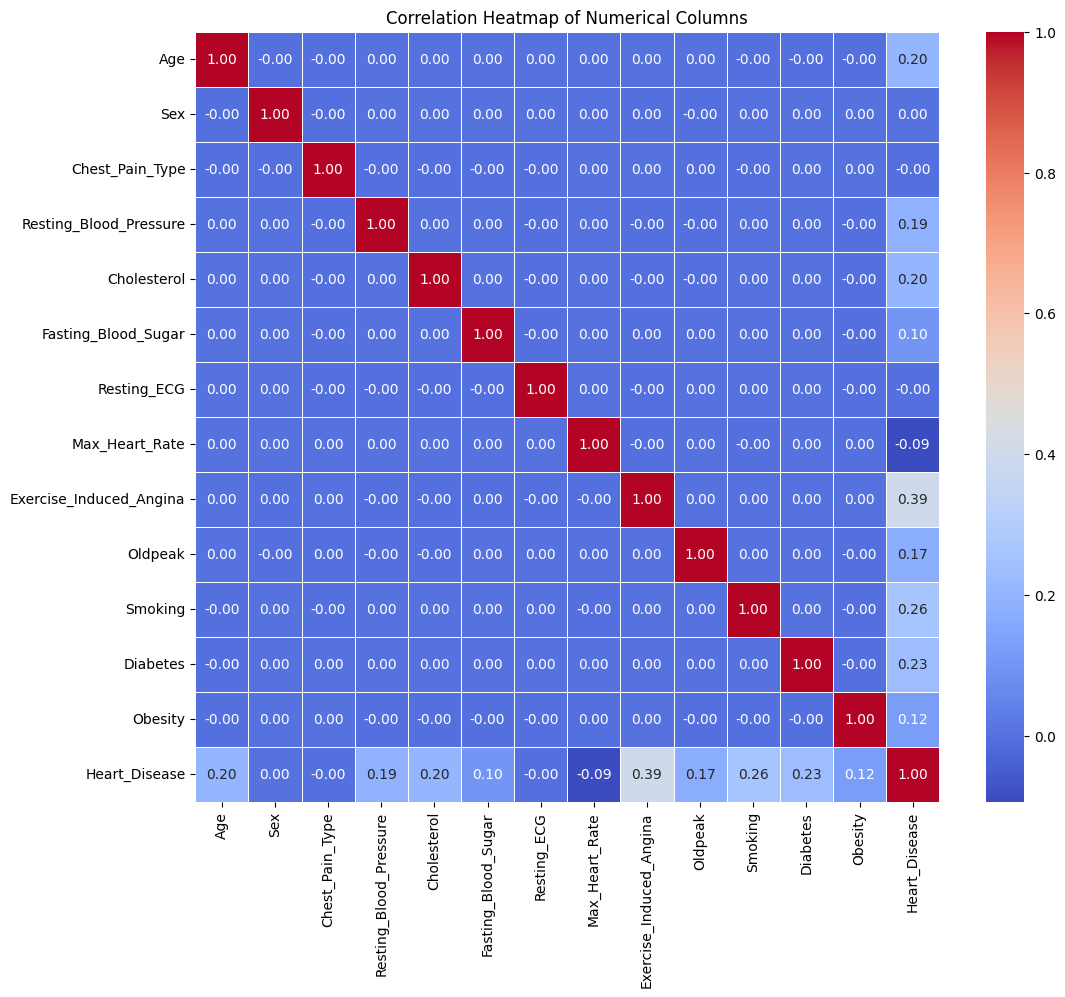

In [5]:
import seaborn as sns
import matplotlib.pyplot as plt

# Calculate the correlation matrix for numerical columns
correlation_matrix = df.corr()

# Set up the matplotlib figure
plt.figure(figsize=(12, 10))

# Draw the heatmap with seaborn
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Heatmap of Numerical Columns')
plt.show()

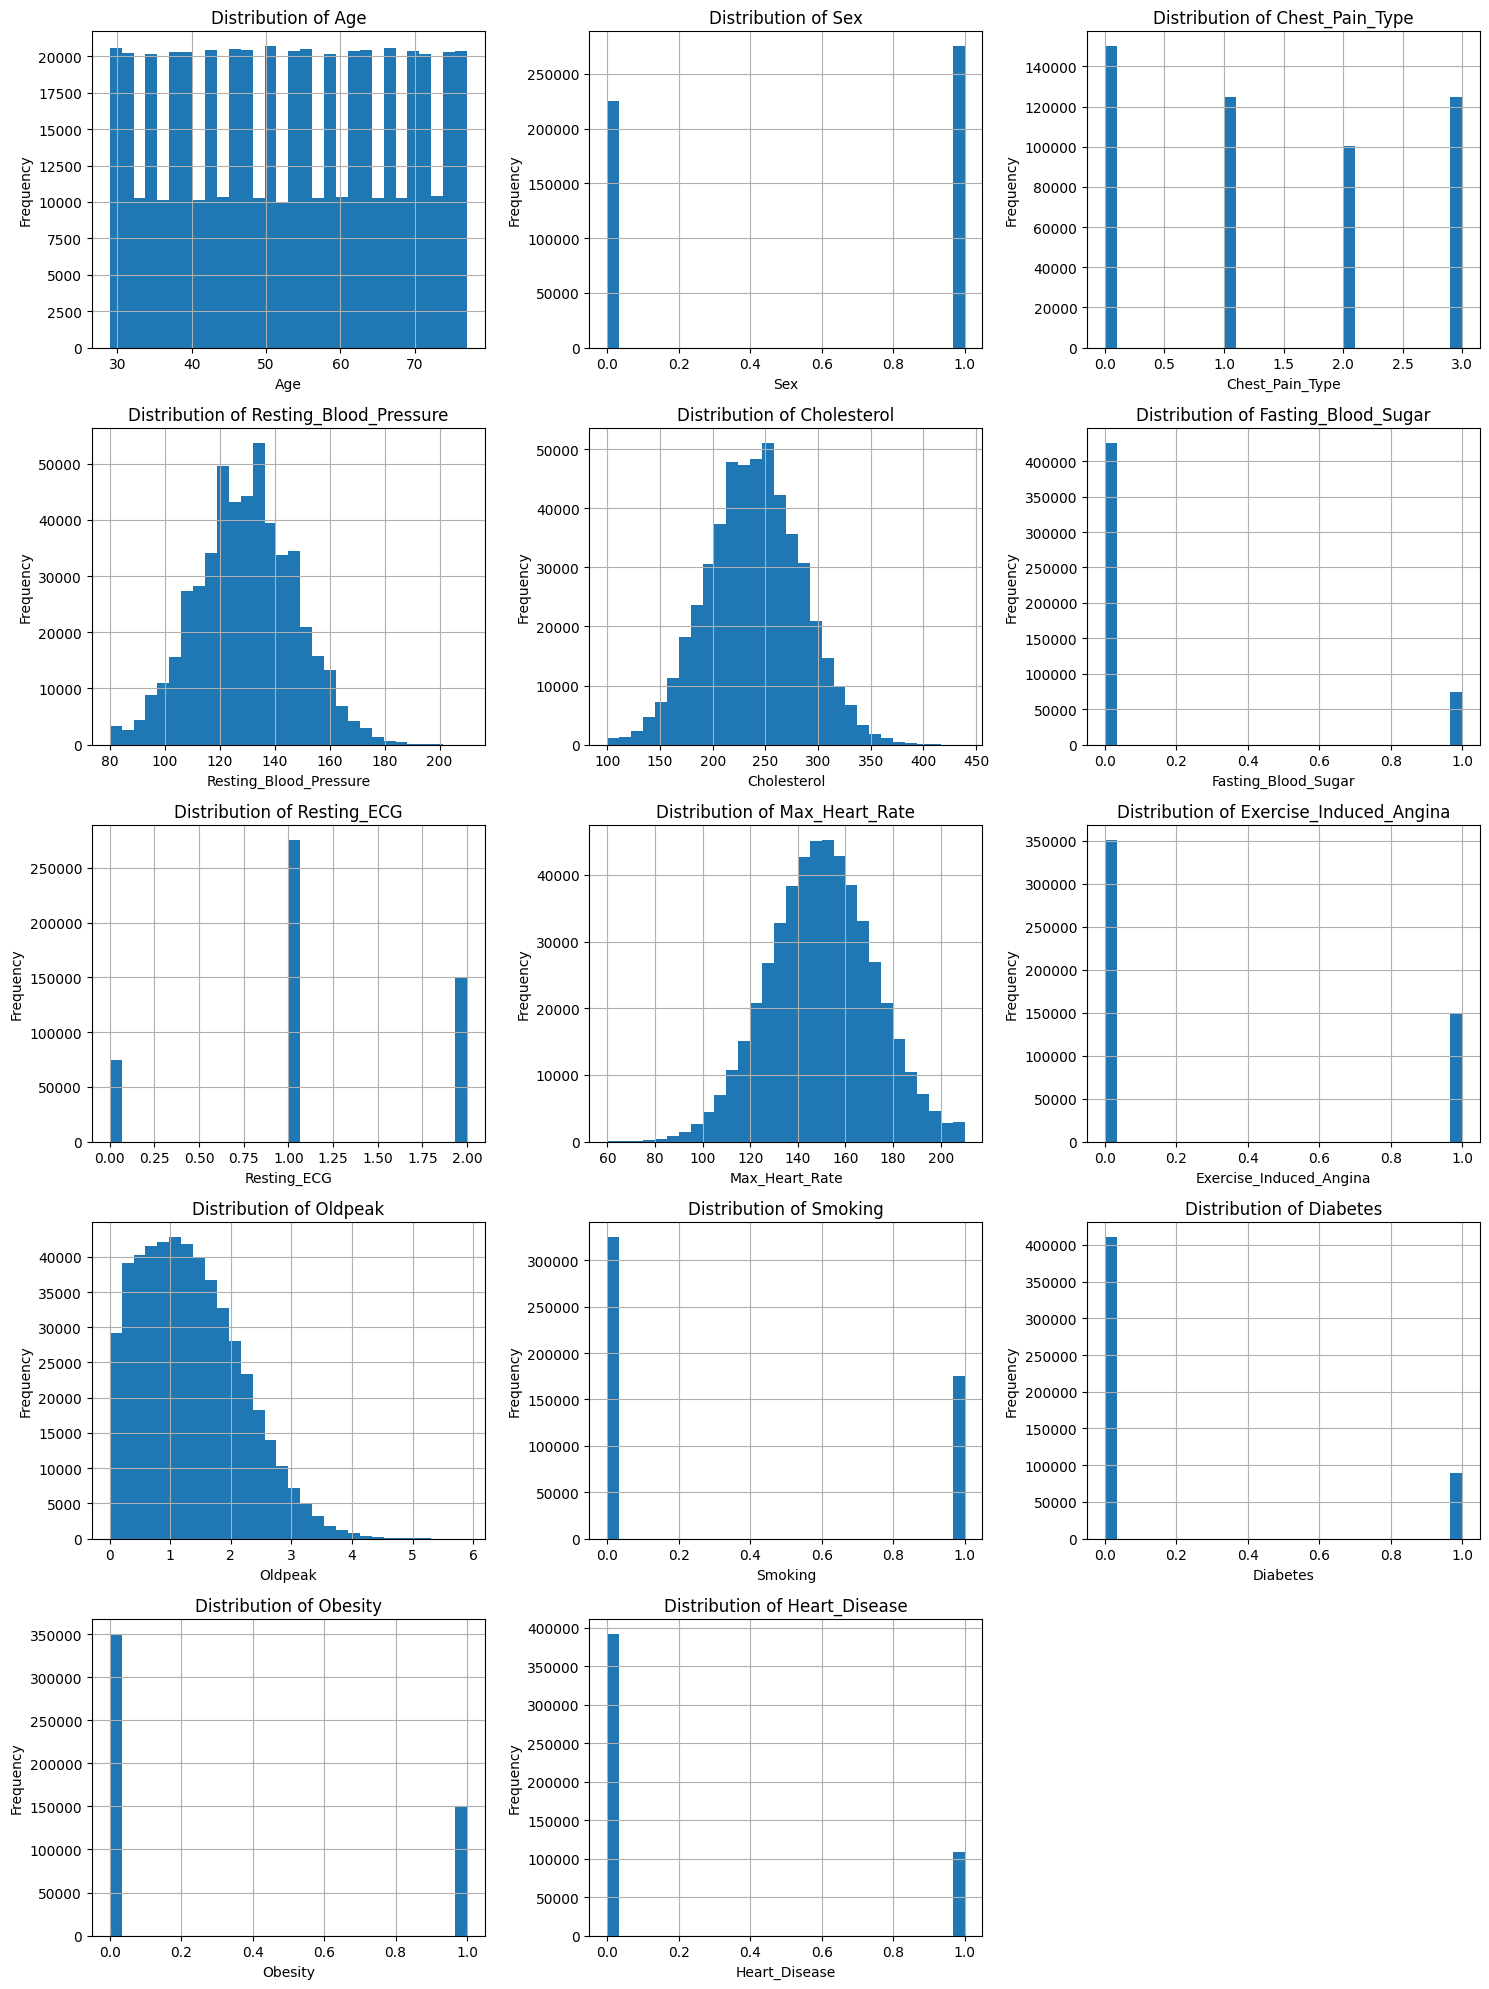

In [6]:
import matplotlib.pyplot as plt

# Select only numerical columns for histogram plotting
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns

# Plot histograms for each numerical column
plt.figure(figsize=(15, 20))
for i, col in enumerate(numerical_cols):
    plt.subplot(len(numerical_cols) // 3 + 1, 3, i + 1) # Adjust subplot grid dynamically
    df[col].hist(bins=30)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

In [7]:
# Menentukan kolom target
target_column = 'Heart_Disease'

# Mengambil nilai korelasi absolut terhadap target
# Kita abaikan baris target itu sendiri
correlations = correlation_matrix[target_column].abs().drop(labels=[target_column])

# Mencari 5 kolom dengan korelasi tertinggi
top_5_features = correlations.sort_values(ascending=False).head(5)

print("5 Kolom yang paling berpengaruh terhadap Heart_Disease:")
print(top_5_features)

5 Kolom yang paling berpengaruh terhadap Heart_Disease:
Exercise_Induced_Angina    0.393505
Smoking                    0.258664
Diabetes                   0.227524
Cholesterol                0.202351
Age                        0.202153
Name: Heart_Disease, dtype: float64


/tmp/ipykernel_18710/2411609384.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=col, data=df, ax=axes[i, 0], palette='viridis')
/tmp/ipykernel_18710/2411609384.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=col, data=df, ax=axes[i, 0], palette='viridis')
/tmp/ipykernel_18710/2411609384.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=col, data=df, ax=axes[i, 0], palette='viridis')


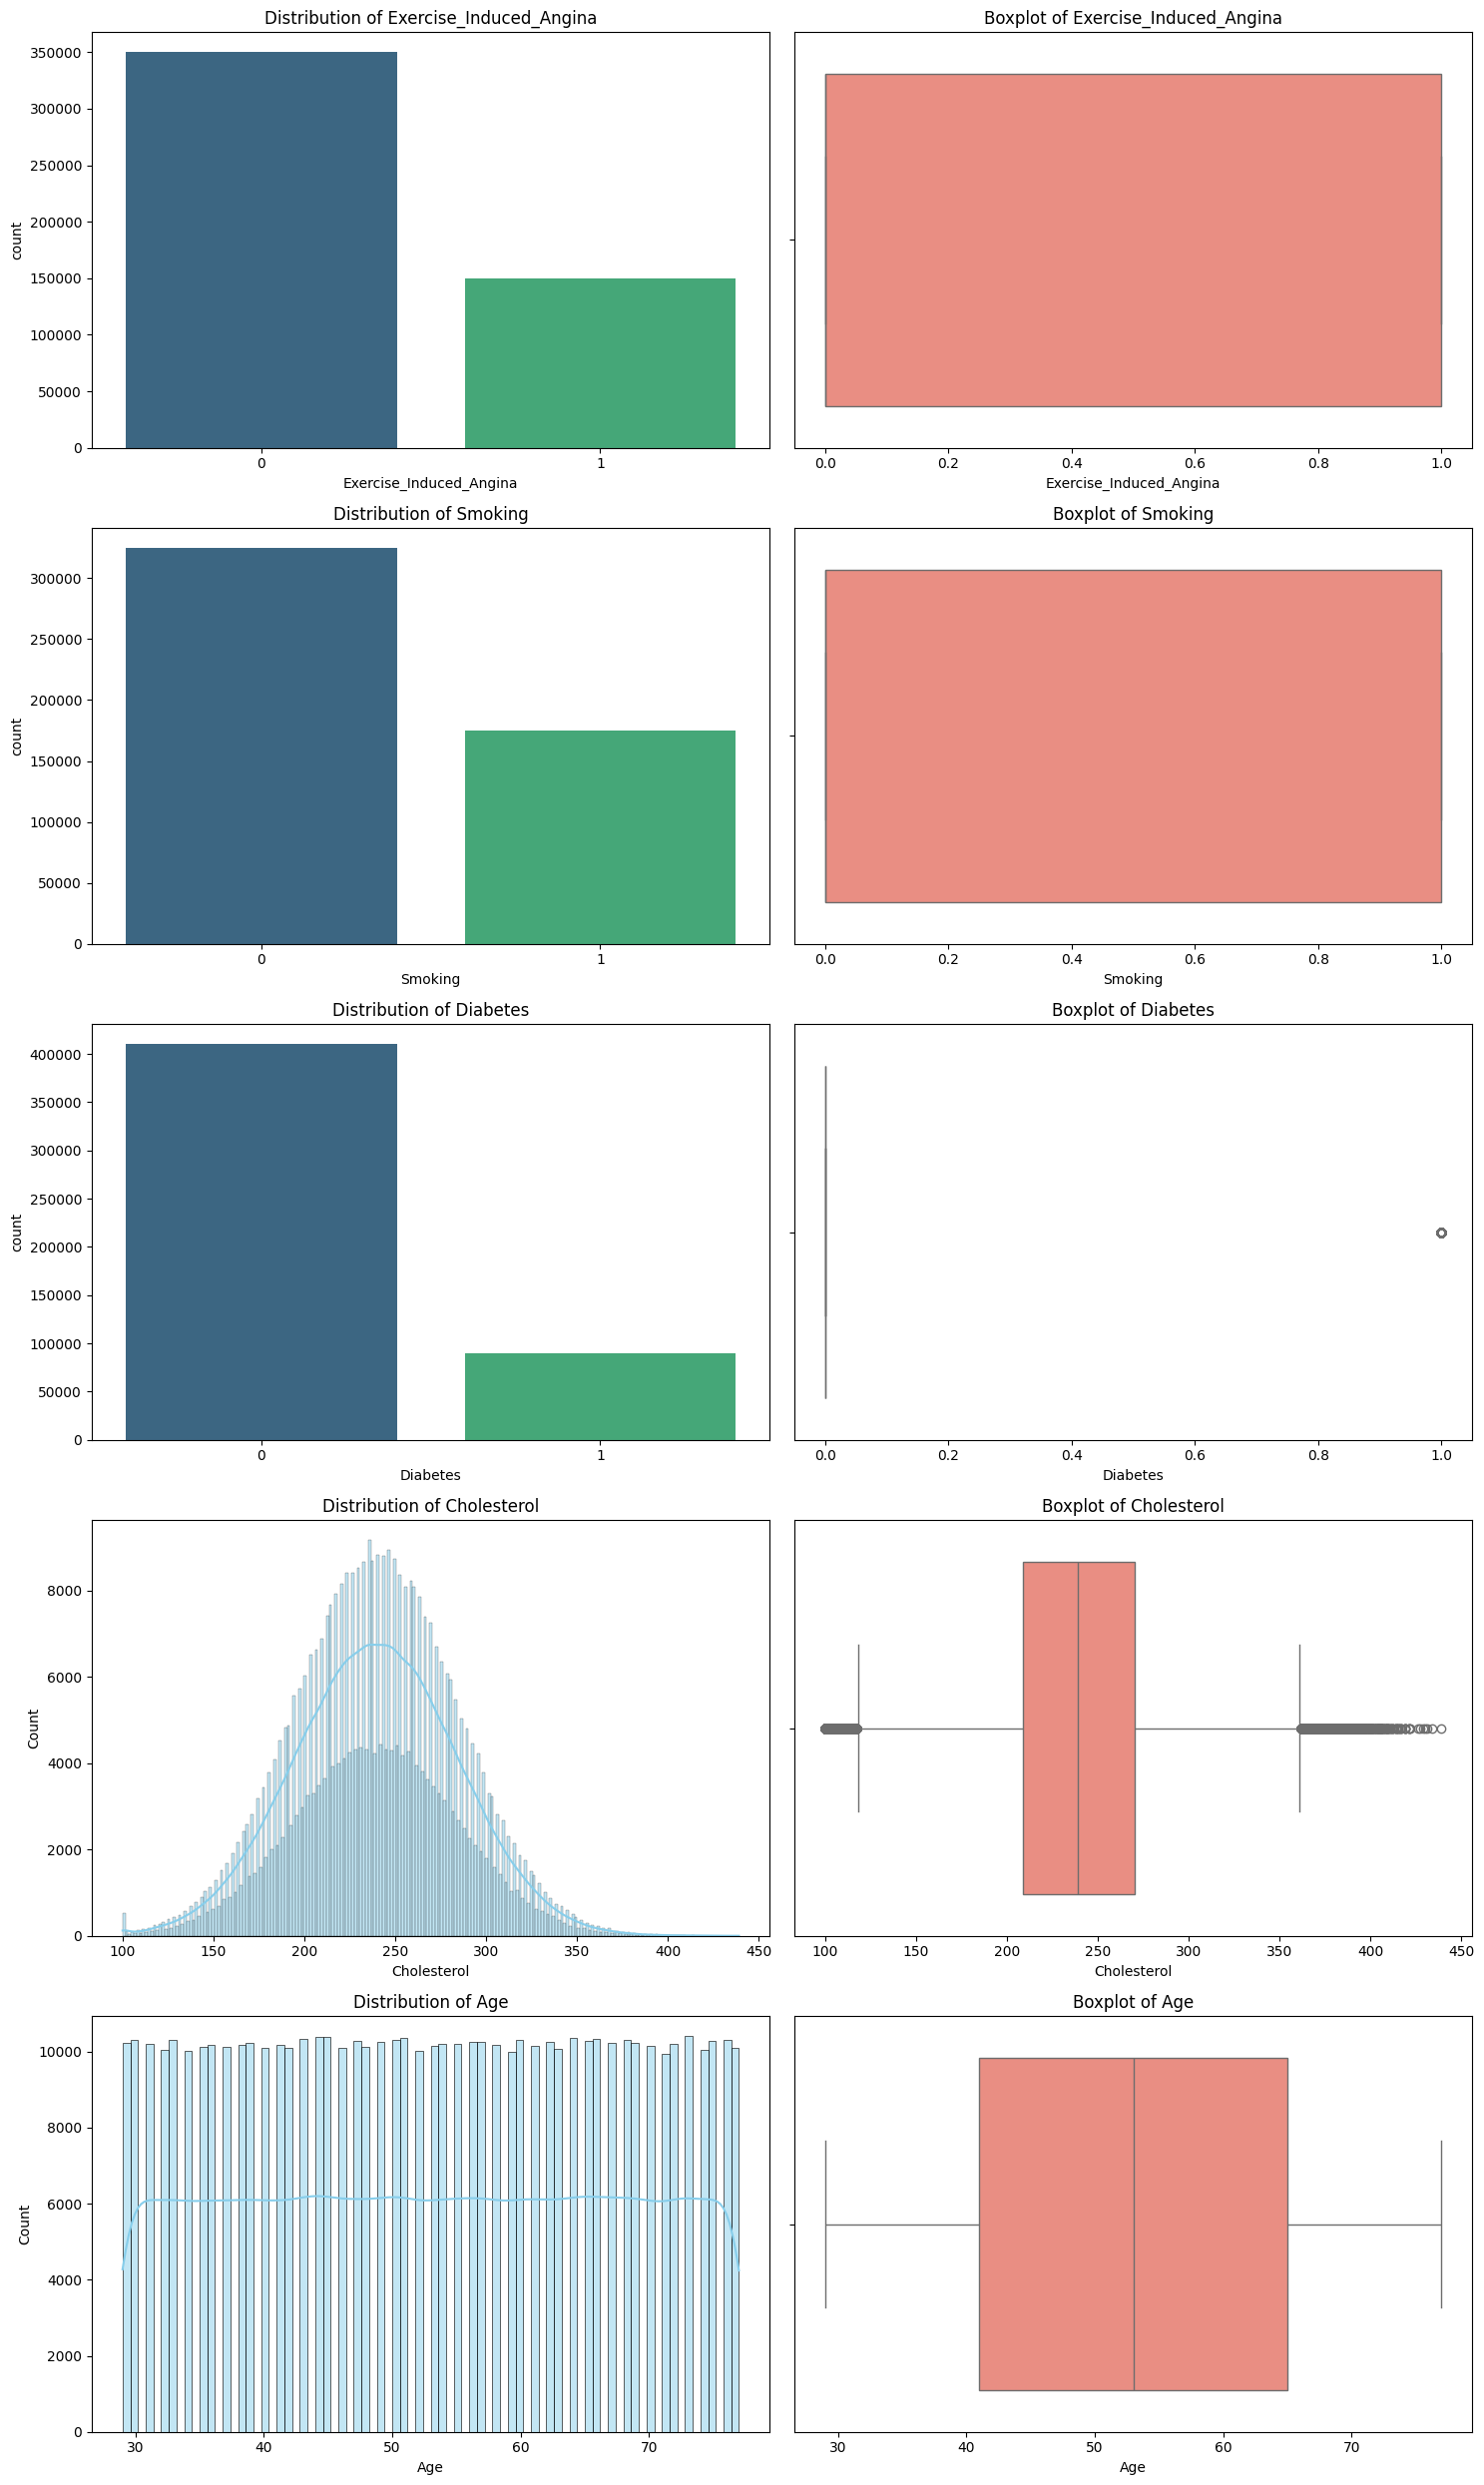

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt

# Identify the top 5 features from previous analysis
top_5_cols = top_5_features.index.tolist()

# Set up the visualization grid
fig, axes = plt.subplots(nrows=len(top_5_cols), ncols=2, figsize=(15, 25))

for i, col in enumerate(top_5_cols):
    # Histogram / Countplot
    if df[col].nunique() <= 2:
        sns.countplot(x=col, data=df, ax=axes[i, 0], palette='viridis')
    else:
        sns.histplot(df[col], kde=True, ax=axes[i, 0], color='skyblue')
    axes[i, 0].set_title(f'Distribution of {col}')

    # Boxplot
    sns.boxplot(x=col, data=df, ax=axes[i, 1], color='salmon')
    axes[i, 1].set_title(f'Boxplot of {col}')

plt.tight_layout()
plt.show()

### Feature Extraction with Deep Learning (Autoencoder)
We will use an Autoencoder architecture to compress the top 5 features into a lower-dimensional representation, effectively performing deep feature extraction.

In [9]:
import tensorflow as tf
from tensorflow.keras import layers, models
from sklearn.preprocessing import StandardScaler

# 1. Prepare data using top 5 features
top_features = top_5_features.index.tolist()
X_top = df[top_features]

# 2. Scale the data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_top)

# 3. Define Autoencoder Architecture
input_dim = X_scaled.shape[1] # which is 5
encoding_dim = 3  # Compress 5 features into 3

# Encoder
input_layer = layers.Input(shape=(input_dim,))
encoded = layers.Dense(16, activation='relu')(input_layer)
encoded = layers.Dense(8, activation='relu')(encoded)
bottleneck = layers.Dense(encoding_dim, activation='relu', name='feature_extractor')(encoded)

# Decoder
decoded = layers.Dense(8, activation='relu')(bottleneck)
decoded = layers.Dense(16, activation='relu')(decoded)
decoded = layers.Dense(input_dim, activation='sigmoid')(decoded)

# Models
autoencoder = models.Model(input_layer, decoded)
encoder = models.Model(input_layer, bottleneck)

autoencoder.compile(optimizer='adam', loss='mse')

# 4. Train the model
print("Training Autoencoder for feature extraction...")
history = autoencoder.fit(X_scaled, X_scaled,
                epochs=20,
                batch_size=256,
                shuffle=True,
                validation_split=0.2,
                verbose=1)

# 5. Extract Features
deep_features = encoder.predict(X_scaled)
print(f"Original shape: {X_scaled.shape}")
print(f"Extracted features shape: {deep_features.shape}")

Training Autoencoder for feature extraction...
Epoch 1/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - loss: 0.6788 - val_loss: 0.6111
Epoch 2/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - loss: 0.6095 - val_loss: 0.6095
Epoch 3/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - loss: 0.6072 - val_loss: 0.6054
Epoch 4/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - loss: 0.6047 - val_loss: 0.6051
Epoch 5/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - loss: 0.6046 - val_loss: 0.6050
Epoch 6/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - loss: 0.6046 - val_loss: 0.6050
Epoch 7/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - loss: 0.6045 - val_loss: 0.6050
Epoch 8/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - loss: 0.6045 - val_loss: 0.6050
Epoch 9/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - loss: 0.6045 - val_loss: 0.6050
Epoch 10/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - loss: 0.6045 - val_loss: 0.6050
Epoch 11/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - loss: 0.6045 - 

In [10]:
import pandas as pd
# Convert extracted features to a DataFrame for easier inspection
df_deep_features = pd.DataFrame(deep_features, columns=[f'Deep_Feature_{i+1}' for i in range(encoding_dim)])
display(df_deep_features.head())

,Deep_Feature_1,Deep_Feature_2,Deep_Feature_3
0,7.248055,5.180325,18.060993
1,9.502007,19.678568,12.209635
2,7.810745,6.746179,17.116566
3,7.757782,8.263895,21.337858
4,7.288128,5.713672,14.788071


In [11]:
from sklearn.cluster import KMeans
import numpy as np

# 1. Initialize and fit K-Means
# We will use 3 clusters as a starting point to analyze the 3 deep features
n_clusters = 3
kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
clusters = kmeans.fit_predict(df_deep_features)

# 2. Define a function to calculate membership (Soft Clustering approach)
# Membership is calculated as the inverse of the distance to the centroid, normalized
def calculate_membership(data, centers):
    # Calculate Euclidean distance to each center
    distances = np.linalg.norm(data[:, np.newaxis] - centers, axis=2)
    # Avoid division by zero
    inv_distances = 1.0 / (distances + 1e-8)
    # Normalize so that memberships sum to 1
    membership = inv_distances / inv_distances.sum(axis=1)[:, np.newaxis]
    return membership

# 3. Calculate memberships for all points
memberships = calculate_membership(df_deep_features.values, kmeans.cluster_centers_)

# 4. Add results back to a DataFrame
membership_cols = [f'Cluster_{i+1}_Membership' for i in range(n_clusters)]
df_membership = pd.DataFrame(memberships, columns=membership_cols)
df_membership['Assigned_Cluster'] = clusters

print("K-Means Centroids:")
print(kmeans.cluster_centers_)
print("\nMembership Functions (First 5 rows):")
display(df_membership.head())

K-Means Centroids:
[[ 7.1061845 14.0190735  8.7299595]
 [ 5.486248   4.752412  17.279245 ]
 [24.803078   7.393247  20.067562 ]]

Membership Functions (First 5 rows):


,Cluster_1_Membership,Cluster_2_Membership,Cluster_3_Membership,Assigned_Cluster
0,0.121478,0.790838,0.087684,1
1,0.565524,0.245525,0.188951,0
2,0.189697,0.688044,0.122259,1
3,0.238580,0.568008,0.193413,1
4,0.210461,0.671746,0.117793,1


### Fuzzy Inference Systems from Scratch
We will define 15 rules mapping the membership of Cluster 1 (High Risk Pattern), Cluster 2 (Low Risk Pattern), and Cluster 3 (Medium Risk Pattern) to a Heart Disease probability.

In [12]:
import numpy as np
import pandas as pd

# 1. Alinyemen Otomatis Cluster Berdasarkan Realita Data (Mengatasi Masalah Acak)
# Kita cari tahu cluster mana yang rata-rata angka penyakit jantungnya paling rendah sampai tertinggi
cluster_risk_profiles = df['Heart_Disease'].groupby(clusters).mean()
sorted_cluster_indices = cluster_risk_profiles.sort_values().index.tolist()

# c_low selalu memegang cluster paling sehat, c_high memegang cluster paling rawan sakit
c_low_all = memberships[:, sorted_cluster_indices[0]]
c_med_all = memberships[:, sorted_cluster_indices[1]]
c_high_all = memberships[:, sorted_cluster_indices[2]]

# 2. Siapkan Data Evaluasi (Gunakan urutan risiko yang sudah lurus)
eval_indices = np.random.choice(len(df), 2000, replace=False)
X_eval_fixed = np.column_stack((c_low_all, c_med_all, c_high_all))[eval_indices]
y_true = df['Heart_Disease'].iloc[eval_indices].values

# Batasan ruang semesta risiko Mamdani
risk_universe = np.linspace(0, 1, 100)

# Fungsi keanggotaan output grafis Mamdani
def mf_low(x): return np.maximum(0, np.minimum(1, (0.4 - x) / 0.4))
def mf_med(x): return np.maximum(0, np.minimum((x - 0.2) / 0.3, (0.8 - x) / 0.3))
def mf_high(x): return np.maximum(0, np.minimum(1, (x - 0.6) / 0.4))

# 3. Model Inferensi Mamdani From Scratch
def mamdani_scratch(row):
    c_low, c_med, c_high = row

    # 15 Aturan Logis terstruktur
    rules = [
        (c_low, 0), (c_med, 1), (c_high, 2),                     # Aturan dasar utama
        (min(c_low, c_med), 0), (min(c_high, c_med), 2),         # Aturan kombinasi AND
        (min(c_low, c_high), 1),
        (c_low**2, 0), (c_med**2, 1), (c_high**2, 2),            # Aturan penekanan kuadrat
        (max(c_high, 0.7), 2), (max(c_low, 0.7), 0),             # Aturan pembatas tegas max
        (min(c_high, 0.5), 2), (min(c_low, 0.5), 0),             # Aturan pemangkasan tengah
        (c_high * c_med, 2), (c_low * c_med, 0)                  # Aturan interaksi produk
    ]

    out_low, out_med, out_high = 0, 0, 0
    for strength, level in rules:
        if level == 0: out_low = max(out_low, strength)
        elif level == 1: out_med = max(out_med, strength)
        else: out_high = max(out_high, strength)

    # Defuzzifikasi Metode Centroid (CoA)
    num = np.sum(risk_universe * np.maximum.reduce([
        np.minimum(out_low, mf_low(risk_universe)),
        np.minimum(out_med, mf_med(risk_universe)),
        np.minimum(out_high, mf_high(risk_universe))
    ]))
    den = np.sum(np.maximum.reduce([
        np.minimum(out_low, mf_low(risk_universe)),
        np.minimum(out_med, mf_med(risk_universe)),
        np.minimum(out_high, mf_high(risk_universe))
    ])) + 1e-9
    return num / den

# 4. Model Inferensi Sugeno From Scratch
def sugeno_scratch(row):
    c_low, c_med, c_high = row

    # Singleton konstan (0.05 = Aman, 0.4 = Waspada, 0.85 = Bahaya)
    rules = [
        (c_low, 0.05), (c_med, 0.4), (c_high, 0.85),
        (min(c_low, c_med), 0.2), (min(c_high, c_med), 0.75), (min(c_low, c_high), 0.4),
        (c_high**2, 0.9), (c_low**2, 0.01), (c_med**2, 0.4),
        (max(c_high, 0.7), 0.85), (max(c_low, 0.7), 0.05),
        (min(c_high, 0.5), 0.75), (min(c_low, 0.5), 0.1),
        (c_high * c_med, 0.8), (c_low * c_med, 0.15)
    ]
    num = sum(strength * output for strength, output in rules)
    den = sum(strength for strength, output in rules) + 1e-9
    return num / den

# 5. Eksekusi Pengujian Performa
mamdani_preds = np.array([mamdani_scratch(r) for r in X_eval_fixed])
sugeno_preds = np.array([sugeno_scratch(r) for r in X_eval_fixed])

# Klasifikasi Biner (Gunakan threshold standard 0.5)
threshold = 0.5
m_acc = ( (mamdani_preds > threshold).astype(int) == y_true ).mean()
s_acc = ( (sugeno_preds > threshold).astype(int) == y_true ).mean()

print(f"Mamdani Model Accuracy: {m_acc:.2%}")
print(f"Sugeno Model Accuracy: {s_acc:.2%}")

Mamdani Model Accuracy: 74.50%
Sugeno Model Accuracy: 72.25%


In [13]:
import numpy as np

# 1. Prepare Data from original features (X_top)
# Using the same eval_indices for a fair comparison
X_raw_eval = X_scaled[eval_indices]

# Helper to define Gaussian-like or Triangle membership functions for normalized inputs
def low_mf(x): return np.maximum(0, 1 - x)
def high_mf(x): return x

# 2. Mamdani from Scratch (Top 5 Features)
def mamdani_raw(row):
    # Exercise_Induced_Angina (f0), Smoking (f1), Diabetes (f2), Cholesterol (f3), Age (f4)
    f = [np.clip(val, 0, 1) for val in row] # Simple clip for membership calculation

    # 15 Rules based on importance
    rules = [
        (f[0], 2), (f[1], 2), (f[2], 1),             # High impact features
        (min(f[0], f[1]), 2), (min(f[3], f[4]), 1),   # Combinations
        (max(f[0], f[2]), 2), (min(f[1], f[4]), 2),
        (1-f[0], 0), (1-f[3], 0), (1-f[4], 0),        # Low risk conditions
        (min(f[3], 0.5), 1), (min(f[0], 0.3), 0),
        (f[0]*f[1], 2), (f[3]*f[4], 1), (f[2]*f[4], 2)
    ]

    out_low, out_med, out_high = 0, 0, 0
    for strength, level in rules:
        if level == 0: out_low = max(out_low, strength)
        elif level == 1: out_med = max(out_med, strength)
        else: out_high = max(out_high, strength)

    num = np.sum(risk_universe * np.maximum.reduce([
        np.minimum(out_low, mf_low(risk_universe)),
        np.minimum(out_med, mf_med(risk_universe)),
        np.minimum(out_high, mf_high(risk_universe))
    ]))
    den = np.sum(np.maximum.reduce([
        np.minimum(out_low, mf_low(risk_universe)),
        np.minimum(out_med, mf_med(risk_universe)),
        np.minimum(out_high, mf_high(risk_universe))
    ])) + 1e-9
    return num / den

# 3. Sugeno from Scratch (Top 5 Features)
def sugeno_raw(row):
    f = [np.clip(val, 0, 1) for val in row]
    rules = [
        (f[0], 0.9), (f[1], 0.8), (f[2], 0.6),
        (min(f[0], f[1]), 0.95), (min(f[3], f[4]), 0.5),
        (max(f[0], f[2]), 0.85), (min(f[1], f[4]), 0.7),
        (1-f[0], 0.1), (1-f[3], 0.2), (1-f[4], 0.25),
        (min(f[3], 0.5), 0.4), (min(f[0], 0.3), 0.1),
        (f[0]*f[1], 0.9), (f[3]*f[4], 0.5), (f[2]*f[4], 0.8)
    ]
    num = sum(strength * output for strength, output in rules)
    den = sum(strength for strength, output in rules) + 1e-9
    return num / den

# 4. Evaluation and Comparison
mamdani_raw_preds = np.array([mamdani_raw(r) for r in X_raw_eval])
sugeno_raw_preds = np.array([sugeno_raw(r) for r in X_raw_eval])

m_raw_acc = ((mamdani_raw_preds > 0.5).astype(int) == y_true).mean()
s_raw_acc = ((sugeno_raw_preds > 0.5).astype(int) == y_true).mean()

print("=== Perbandingan Akurasi Model Fuzzy ===")
print(f"Mamdani (Cluster-based): {m_acc:.2%}")
print(f"Sugeno (Cluster-based): {s_acc:.2%}")
print(f"Mamdani (Raw Top-5): {m_raw_acc:.2%}")
print(f"Sugeno (Raw Top-5): {s_raw_acc:.2%}")

=== Perbandingan Akurasi Model Fuzzy ===
Mamdani (Cluster-based): 74.50%
Sugeno (Cluster-based): 72.25%
Mamdani (Raw Top-5): 82.25%
Sugeno (Raw Top-5): 74.40%


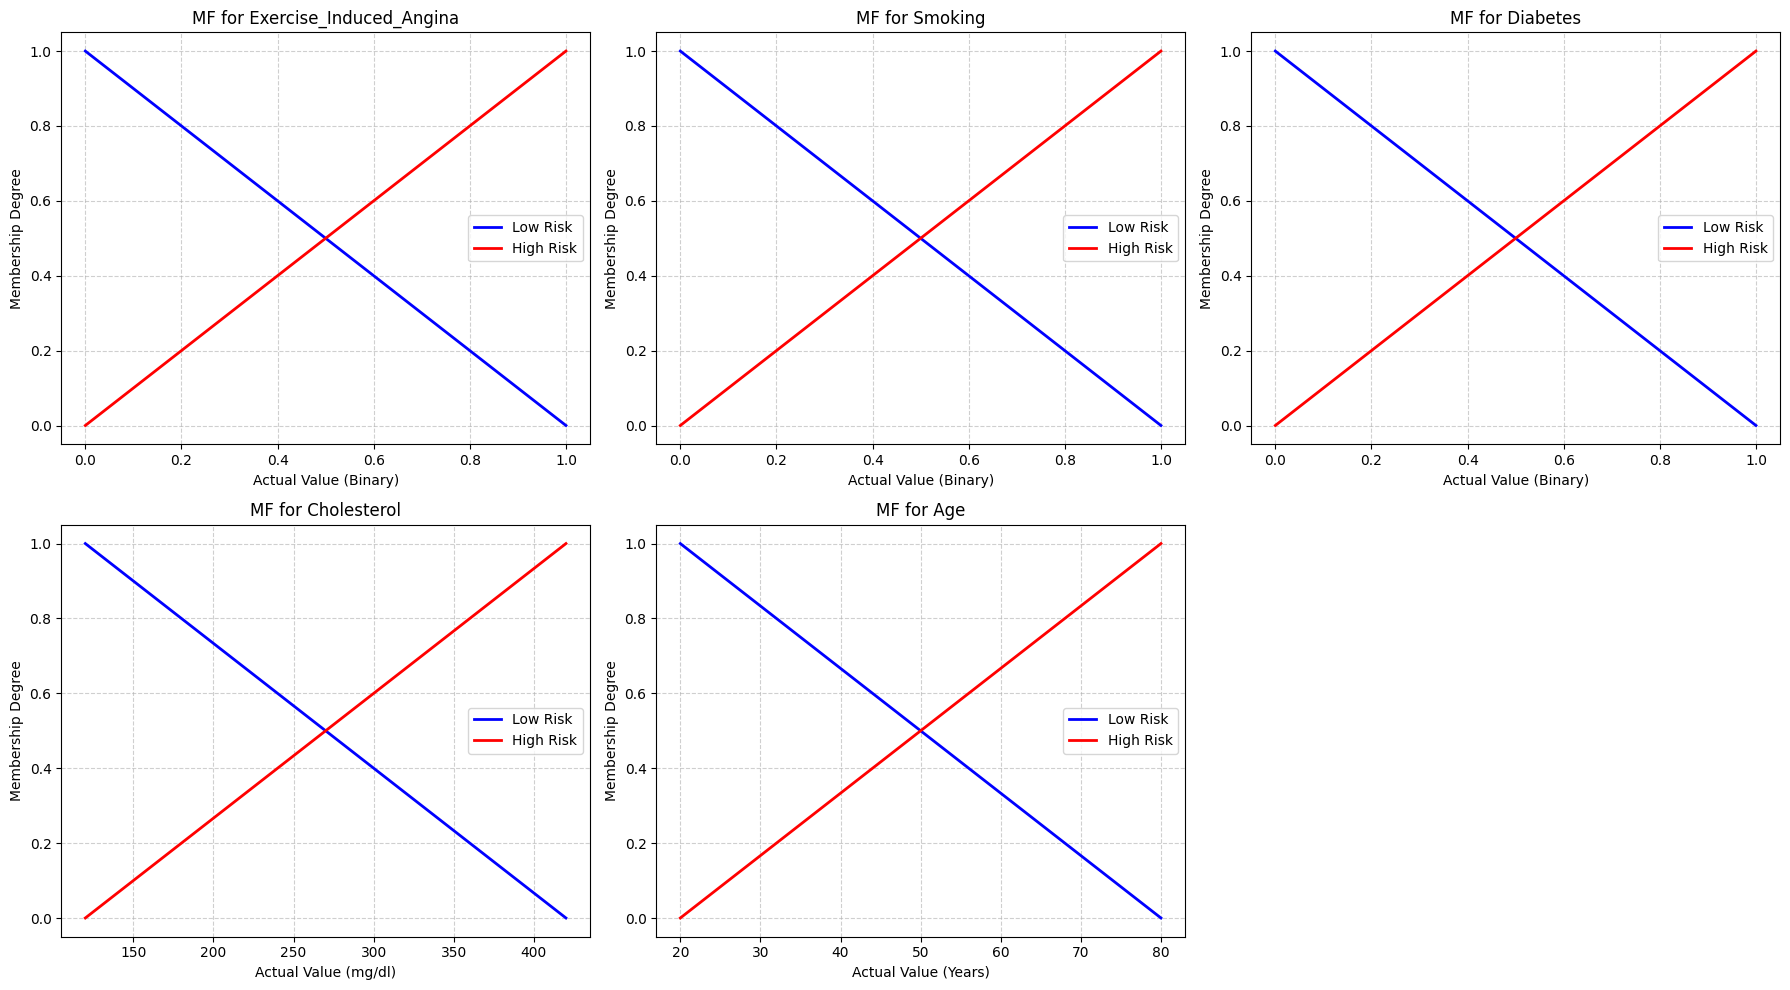

In [14]:
import matplotlib.pyplot as plt
import numpy as np

# Define feature ranges based on the dataset logic used in app.py
feature_configs = {
    'Exercise_Induced_Angina': (0, 1, 'Binary'),
    'Smoking': (0, 1, 'Binary'),
    'Diabetes': (0, 1, 'Binary'),
    'Cholesterol': (120, 420, 'mg/dl'),
    'Age': (20, 80, 'Years')
}

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, (feature, config) in enumerate(feature_configs.items()):
    min_val, max_val, unit = config
    x_range = np.linspace(min_val, max_val, 100)

    # Calculate MFs based on the scale
    # Low: 1 at min, 0 at max
    y_low = (max_val - x_range) / (max_val - min_val)
    # High: 0 at min, 1 at max
    y_high = (x_range - min_val) / (max_val - min_val)

    ax = axes[i]
    ax.plot(x_range, y_low, 'b', linewidth=2, label='Low Risk')
    ax.plot(x_range, y_high, 'r', linewidth=2, label='High Risk')
    ax.set_title(f'MF for {feature}')
    ax.set_xlabel(f'Actual Value ({unit})')
    ax.set_ylabel('Membership Degree')
    ax.legend()
    ax.grid(True, linestyle='--', alpha=0.6)

# Hide the empty 6th subplot
axes[-1].axis('off')

plt.tight_layout()
plt.show()

In [15]:
%%writefile app.py
import streamlit as st
import numpy as np

# --- Fuzzy Logic Functions ---
risk_universe = np.linspace(0, 1, 100)
def mf_low(x): return np.maximum(0, np.minimum(1, (0.4 - x) / 0.4))
def mf_med(x): return np.maximum(0, np.minimum((x - 0.2) / 0.3, (0.8 - x) / 0.3))
def mf_high(x): return np.maximum(0, np.minimum(1, (x - 0.6) / 0.4))

def mamdani_raw(row):
    f = [np.clip(val, 0, 1) for val in row]
    rules = [
        (f[0], 2), (f[1], 2), (f[2], 1),
        (min(f[0], f[1]), 2), (min(f[3], f[4]), 1),
        (max(f[0], f[2]), 2), (min(f[1], f[4]), 2),
        (1-f[0], 0), (1-f[3], 0), (1-f[4], 0),
        (min(f[3], 0.5), 1), (min(f[0], 0.3), 0),
        (f[0]*f[1], 2), (f[3]*f[4], 1), (f[2]*f[4], 2)
    ]
    out_low, out_med, out_high = 0, 0, 0
    for strength, level in rules:
        if level == 0: out_low = max(out_low, strength)
        elif level == 1: out_med = max(out_med, strength)
        else: out_high = max(out_high, strength)
    num = np.sum(risk_universe * np.maximum.reduce([
        np.minimum(out_low, mf_low(risk_universe)),
        np.minimum(out_med, mf_med(risk_universe)),
        np.minimum(out_high, mf_high(risk_universe))
    ]))
    den = np.sum(np.maximum.reduce([
        np.minimum(out_low, mf_low(risk_universe)),
        np.minimum(out_med, mf_med(risk_universe)),
        np.minimum(out_high, mf_high(risk_universe))
    ])) + 1e-9
    return num / den

def sugeno_raw(row):
    f = [np.clip(val, 0, 1) for val in row]
    rules = [
        (f[0], 0.9), (f[1], 0.8), (f[2], 0.6),
        (min(f[0], f[1]), 0.95), (min(f[3], f[4]), 0.5),
        (max(f[0], f[2]), 0.85), (min(f[1], f[4]), 0.7),
        (1-f[0], 0.1), (1-f[3], 0.2), (1-f[4], 0.25),
        (min(f[3], 0.5), 0.4), (min(f[0], 0.3), 0.1),
        (f[0]*f[1], 0.9), (f[3]*f[4], 0.5), (f[2]*f[4], 0.8)
    ]
    num = sum(strength * output for strength, output in rules)
    den = sum(strength for strength, output in rules) + 1e-9
    return num / den

# --- Streamlit UI ---
st.title("Heart Disease Prediction - Fuzzy Logic")
st.write("Silakan masukkan data pasien di bawah ini.")

# Inputs
col_a, col_b = st.columns(2)
with col_a:
    age = st.number_input("Umur (Tahun)", min_value=1, max_value=120, value=45)
    chol = st.number_input("Kolesterol (mg/dl)", min_value=100, max_value=600, value=200)
with col_b:
    smoking = st.selectbox("Apakah Pasien Merokok?", ["No", "Yes"])
    diabetes = st.selectbox("Apakah Pasien Diabetes?", ["No", "Yes"])
    exang = st.selectbox("Nyeri Dada Saat Olahraga? (Exercise Induced Angina)", ["No", "Yes"])

# Normalize inputs to 0-1 range for the model
# Assuming typical min-max from common heart datasets
f_age = (age - 20) / 60  # Scale age 20-80 to 0-1
f_chol = (chol - 120) / 300 # Scale chol 120-420 to 0-1
f_smoking = 1.0 if smoking == "Yes" else 0.0
f_diabetes = 1.0 if diabetes == "Yes" else 0.0
f_exang = 1.0 if exang == "Yes" else 0.0

# Internal feature order: [Exercise, Smoking, Diabetes, Cholesterol, Age]
input_data = [f_exang, f_smoking, f_diabetes, f_chol, f_age]

if st.button("Prediksi Risiko"):
    m_res = mamdani_raw(input_data)
    s_res = sugeno_raw(input_data)

    st.divider()
    c1, c2 = st.columns(2)
    c1.metric("Skor Mamdani", f"{m_res:.2%}")
    c2.metric("Skor Sugeno", f"{s_res:.2%}")

    if m_res > 0.6:
        st.error("Status: RISIKO TINGGI")
    elif m_res > 0.3:
        st.warning("Status: RISIKO SEDANG")
    else:
        st.success("Status: RISIKO RENDAH")

Overwriting app.py


In [16]:
from google.colab import files

# Mendownload file app.py versi terbaru yang sudah diperbarui inputnya
files.download('app.py')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>